# TeleComCo: Predicting Customer Churn

## Part A: Data Understanding & Preparation
### Explore dataset structure, summary statsﬁcs, and patterns (distributions)
### Identify missing values, outliers and class imbalance

In [305]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import imblearn
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

In [306]:
churn = pd.read_excel("https://raw.githubusercontent.com/ttchuang/dataset/master/Churn.xlsx")
churn.head()
#churn.shape
churn.info()

<class 'pandas.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   State           3333 non-null   str    
 1   Account Length  3333 non-null   int64  
 2   Area Code       3333 non-null   int64  
 3   Phone           3333 non-null   str    
 4   Intl Plan       3333 non-null   str    
 5   VMail Plan      3333 non-null   str    
 6   VMail Message   3333 non-null   int64  
 7   Day Mins        3333 non-null   float64
 8   Day Calls       3333 non-null   int64  
 9   Day Charge      3333 non-null   float64
 10  Eve Mins        3333 non-null   float64
 11  Eve Calls       3333 non-null   int64  
 12  Eve Charge      3333 non-null   float64
 13  Night Mins      3333 non-null   float64
 14  Night Calls     3333 non-null   int64  
 15  Night Charge    3333 non-null   float64
 16  Intl Mins       3333 non-null   float64
 17  Intl Calls      3333 non-null   int64  
 18 

In [307]:
# check potential redundancy between 'Old Churn' and 'Churn' columns, ignoreing decimal point differences
diff_count = (churn['Old Churn'].astype(str).str.rstrip('.') != churn['Churn'].astype(str)).sum()

if diff_count == 0:
    print(f"'Old Churn' and 'Churn' are identical across all rows.")
    
    # Since they are identical, we can safely drop one of the columns to avoid redundancy
    churn.drop(columns=['Old Churn'], inplace=True)
    print(" 'Old Churn' column deleted.")
    
else:
    print(f"There are {diff_count} rows where 'Old Churn' and 'Churn' differ. Please investigate further before dropping any columns.")

churn.head()


'Old Churn' and 'Churn' are identical across all rows.
 'Old Churn' column deleted.


,State,Account Length,Area Code,Phone,Intl Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [308]:
# -- add labels of 'Churn','Intl Plan' and 'VMail Plan' to the dataframe --
# -- 1: True / yes --
# -- 0: False / no --
# change 'Area Code' to string variable
churn['Area Code'] = churn['Area Code'].astype('str')
churn['Intl Plan'] = churn['Intl Plan'].apply(lambda x: 1 if(x== 'yes' ) else 0)
churn['VMail Plan'] = churn['VMail Plan'].apply(lambda x: 1 if(x== 'yes' ) else 0)
churn['Churn_Status'] = churn['Churn'].apply(lambda x: 'Churned' if(x== True ) else 'Retained')
churn['Churn'] = churn['Churn'].apply(lambda x: 1 if(x== True ) else 0)
churn.head()

,State,Account Length,Area Code,Phone,Intl Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn,Churn_Status
0,KS,128,415,382-4657,0,1,25,265.1,110,45.07,...,16.78,244.7,91,11.01,10.0,3,2.70,1,0,Retained
1,OH,107,415,371-7191,0,1,26,161.6,123,27.47,...,16.62,254.4,103,11.45,13.7,3,3.70,1,0,Retained
2,NJ,137,415,358-1921,0,0,0,243.4,114,41.38,...,10.30,162.6,104,7.32,12.2,5,3.29,0,0,Retained
3,OH,84,408,375-9999,1,0,0,299.4,71,50.90,...,5.26,196.9,89,8.86,6.6,7,1.78,2,0,Retained
4,OK,75,415,330-6626,1,0,0,166.7,113,28.34,...,12.61,186.9,121,8.41,10.1,3,2.73,3,0,Retained


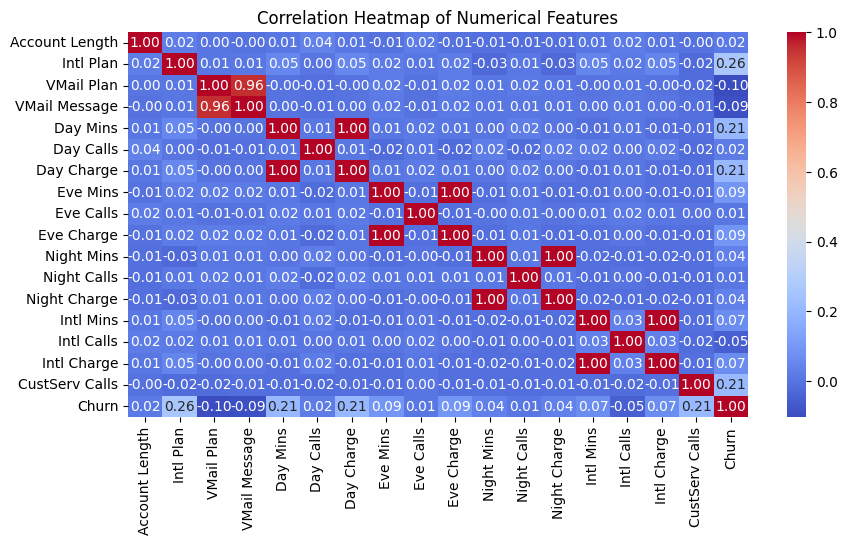

In [309]:
# use heatmap to visualize the correlation between numerical features
corr_matrix = churn.select_dtypes(include=['float64', 'int64']).corr()

plt.figure(figsize=(10, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

--- Columns remaining after dropping redundant charge features ---
['State', 'Account Length', 'Area Code', 'Phone', 'Intl Plan', 'VMail Message', 'Day Mins', 'Day Calls', 'Eve Mins', 'Eve Calls', 'Night Mins', 'Night Calls', 'Intl Mins', 'Intl Calls', 'CustServ Calls', 'Churn', 'Churn_Status']


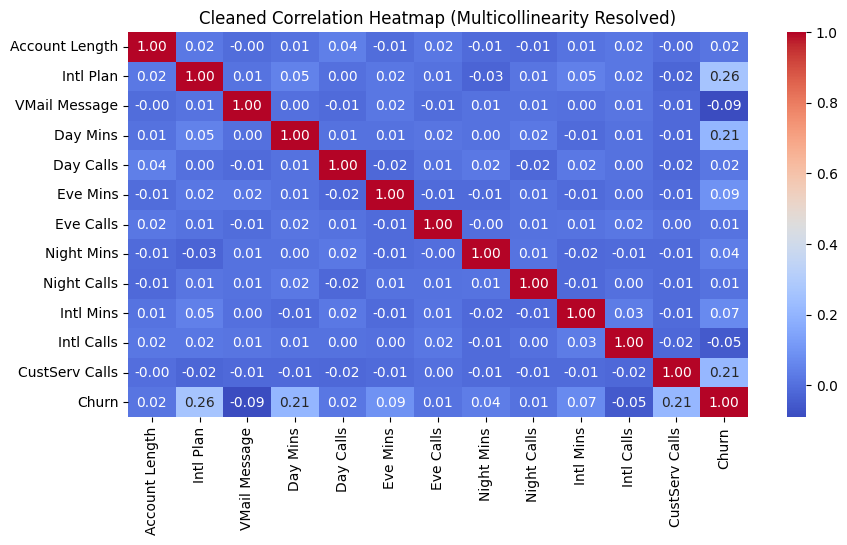

In [310]:
# 1. Define the list of redundant columns based on the heatmap
# These columns have a 1.00 / 0.96 correlation 
cols_to_drop = ['Day Charge', 'Eve Charge', 'Night Charge', 'Intl Charge', 'VMail Plan']

# 2. Drop the redundant columns from the DataFrame
# axis=1 specifies we are dropping columns, inplace=True applies it to the current df
churn.drop(columns=cols_to_drop, inplace=True)

# 3. Verify the remaining columns
print("--- Columns remaining after dropping redundant charge features ---")
print(churn.columns.tolist())

# 4. Optional: Regenerate the heatmap to confirm multicollinearity is resolved
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
# Select only numeric types for correlation calculation
numeric_churn = churn.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_churn.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Cleaned Correlation Heatmap (Multicollinearity Resolved)')
plt.show()

In [311]:
churn.info()

<class 'pandas.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   State           3333 non-null   str    
 1   Account Length  3333 non-null   int64  
 2   Area Code       3333 non-null   str    
 3   Phone           3333 non-null   str    
 4   Intl Plan       3333 non-null   int64  
 5   VMail Message   3333 non-null   int64  
 6   Day Mins        3333 non-null   float64
 7   Day Calls       3333 non-null   int64  
 8   Eve Mins        3333 non-null   float64
 9   Eve Calls       3333 non-null   int64  
 10  Night Mins      3333 non-null   float64
 11  Night Calls     3333 non-null   int64  
 12  Intl Mins       3333 non-null   float64
 13  Intl Calls      3333 non-null   int64  
 14  CustServ Calls  3333 non-null   int64  
 15  Churn           3333 non-null   int64  
 16  Churn_Status    3333 non-null   str    
dtypes: float64(4), int64(9), str(4)
memory usage

In [312]:
# Set 'Phone' as index to uniquely identify customers.
# Reorder columns: numerical features first, then string features.

# Step 1: Set 'Phone' as the index
churn = churn.set_index('Phone')

# Step 2: Separate numerical and string columns
# Get all numerical columns (int64 + float64)
numeric_cols = churn.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Get all string columns
str_cols = churn.select_dtypes(include=['object', 'string']).columns.tolist()

# Step 3: Reorder columns: numeric first, then string
new_order = numeric_cols + str_cols
churn = churn[new_order]

# Step 4: Verify the result
churn.head()

,Account Length,Intl Plan,VMail Message,Day Mins,Day Calls,Eve Mins,Eve Calls,Night Mins,Night Calls,Intl Mins,Intl Calls,CustServ Calls,Churn,State,Area Code,Churn_Status
Phone,,,,,,,,,,,,,,,,
382-4657,128,0,25,265.1,110,197.4,99,244.7,91,10.0,3,1,0,KS,415,Retained
371-7191,107,0,26,161.6,123,195.5,103,254.4,103,13.7,3,1,0,OH,415,Retained
358-1921,137,0,0,243.4,114,121.2,110,162.6,104,12.2,5,0,0,NJ,415,Retained
375-9999,84,1,0,299.4,71,61.9,88,196.9,89,6.6,7,2,0,OH,408,Retained
330-6626,75,1,0,166.7,113,148.3,122,186.9,121,10.1,3,3,0,OK,415,Retained


In [313]:
# check missing values
churn.isnull().sum()


Account Length    0
Intl Plan         0
VMail Message     0
Day Mins          0
Day Calls         0
Eve Mins          0
Eve Calls         0
Night Mins        0
Night Calls       0
Intl Mins         0
Intl Calls        0
CustServ Calls    0
Churn             0
State             0
Area Code         0
Churn_Status      0
dtype: int64

Outlier Detection Results (IQR Method)
       Feature    Q1    Q3  IQR  Lower Bound  Upper Bound  Outlier Count  Outlier Percentage
Account Length  74.0 127.0 53.0        -5.50       206.50             18                0.54
 VMail Message   0.0  20.0 20.0       -30.00        50.00              1                0.03
      Day Mins 143.7 216.4 72.7        34.65       325.45             25                0.75
     Day Calls  87.0 114.0 27.0        46.50       154.50             23                0.69
      Eve Mins 166.6 235.3 68.7        63.55       338.35             24                0.72
     Eve Calls  87.0 114.0 27.0        46.50       154.50             20                0.60
    Night Mins 167.0 235.3 68.3        64.55       337.75             30                0.90
   Night Calls  87.0 113.0 26.0        48.00       152.00             22                0.66
     Intl Mins   8.5  12.1  3.6         3.10        17.50             46                1.38
    Intl Calls   3.0   6.0  3.0

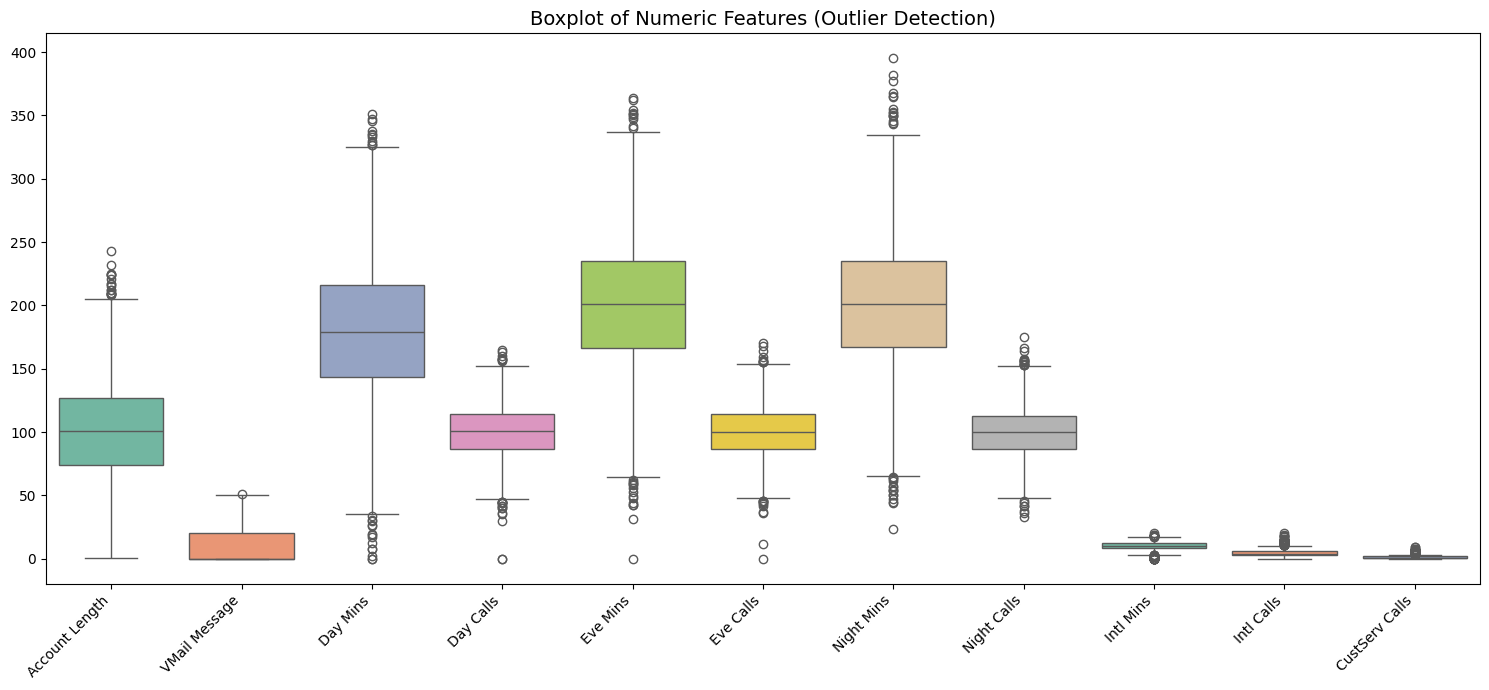

In [314]:
# check outlier values

# Define numeric features for outlier detection
numeric_features = [
    'Account Length', 'VMail Message', 'Day Mins', 'Day Calls',
    'Eve Mins', 'Eve Calls', 'Night Mins', 'Night Calls',
    'Intl Mins', 'Intl Calls', 'CustServ Calls'
]

def detect_outliers_iqr(df, feature):
    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    # Count outliers
    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    return {
        "Feature": feature,
        "Q1": round(q1, 2),
        "Q3": round(q3, 2),
        "IQR": round(iqr, 2),
        "Lower Bound": round(lower_bound, 2),
        "Upper Bound": round(upper_bound, 2),
        "Outlier Count": len(outliers),
        "Outlier Percentage": round(len(outliers) / len(df) * 100, 2)
    }

# Run detection for all numeric features
outlier_results = [detect_outliers_iqr(churn, feat) for feat in numeric_features]

# Generate summary table
outlier_df = pd.DataFrame(outlier_results)
print("Outlier Detection Results (IQR Method)")
print("=" * 100)
print(outlier_df.to_string(index=False))

# Visualize outliers with boxplots
plt.figure(figsize=(15, 7))
sns.boxplot(data=churn[numeric_features], palette="Set2")
plt.title("Boxplot of Numeric Features (Outlier Detection)", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [315]:
# check the distribution of the target variable
print(churn['Churn'].value_counts())

Churn
0    2850
1     483
Name: count, dtype: int64


#### Summary of missing value, outliers and class imbalance
* missing value: all features have zero missing values.
* outlier detection: Most numeric features have extremely low outlier percentages (below 2.5%), which is well within the normal range for real-world customer behavior data. The only feature with a notably higher outlier rate is `CustServ Calls` (8.01%). Critically, these outliers are not data errors: they represent customers with 4 or more customer service contacts, a clear and meaningful business signal of customer dissatisfaction and elevated churn risk. Removing these values would eliminate critical predictive information for churn modeling, so we retain all outliers in the dataset. 
* class imbalance analysis: the target variable `Churn` reveals that the dataset is imbalanced: 2850 customers (85.5%) did not churn, while only 483 customers (14.5%) churned. This imbalance is typical for customer churn datasets, as the majority of customers remain active. To address this, we apply `class_weight='balanced'` in distance-based models (SVM) and leverage the inherent robustness of tree-based models (Random Forest) to imbalanced data, ensuring the model does not bias toward the majority non-churn class and can effectively identify at-risk customers.

## Part B: Exploratory Data Analysis (EDA)
### Analyze relationships between variables and churn
### Visualizations: histograms, boxplots, correlation heatmap, etc.

In [316]:
churn.head()

,Account Length,Intl Plan,VMail Message,Day Mins,Day Calls,Eve Mins,Eve Calls,Night Mins,Night Calls,Intl Mins,Intl Calls,CustServ Calls,Churn,State,Area Code,Churn_Status
Phone,,,,,,,,,,,,,,,,
382-4657,128,0,25,265.1,110,197.4,99,244.7,91,10.0,3,1,0,KS,415,Retained
371-7191,107,0,26,161.6,123,195.5,103,254.4,103,13.7,3,1,0,OH,415,Retained
358-1921,137,0,0,243.4,114,121.2,110,162.6,104,12.2,5,0,0,NJ,415,Retained
375-9999,84,1,0,299.4,71,61.9,88,196.9,89,6.6,7,2,0,OH,408,Retained
330-6626,75,1,0,166.7,113,148.3,122,186.9,121,10.1,3,3,0,OK,415,Retained


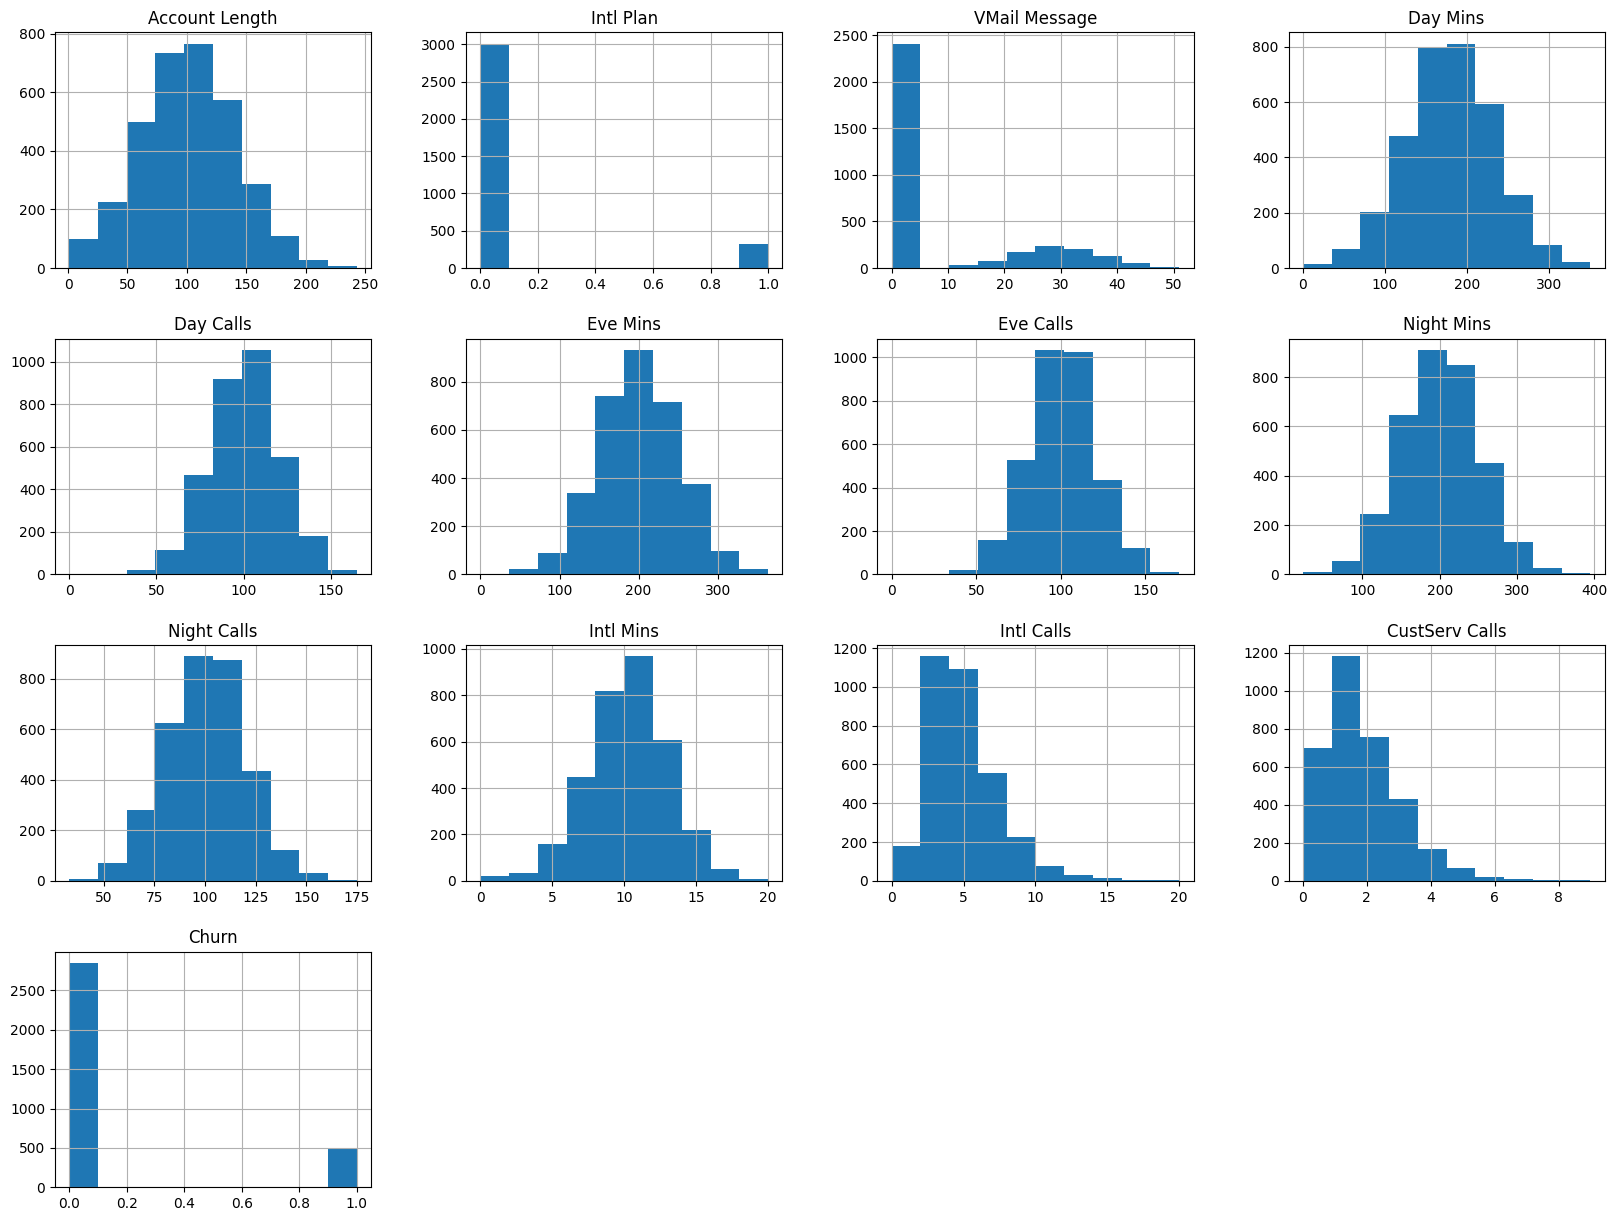

In [317]:
# identify relationships between numerical features and the target variable
# -- visualize the distribution of the target variable --
churn.iloc[:,:-3].hist(bins=10,figsize=(20,15))
plt.show();

In [318]:
# -- find correlations between numerical features --
mx = churn.iloc[:,:-3].corr()
mx 

,Account Length,Intl Plan,VMail Message,Day Mins,Day Calls,Eve Mins,Eve Calls,Night Mins,Night Calls,Intl Mins,Intl Calls,CustServ Calls,Churn
Account Length,1.000000,0.024735,-0.004628,0.006216,0.038470,-0.006757,0.019260,-0.008955,-0.013176,0.009514,0.020661,-0.003796,0.016541
Intl Plan,0.024735,1.000000,0.008745,0.049396,0.003755,0.019100,0.006114,-0.028905,0.012451,0.045871,0.017366,-0.024522,0.259852
VMail Message,-0.004628,0.008745,1.000000,0.000778,-0.009548,0.017562,-0.005864,0.007681,0.007123,0.002856,0.013957,-0.013263,-0.089728
Day Mins,0.006216,0.049396,0.000778,1.000000,0.006750,0.007043,0.015769,0.004323,0.022972,-0.010155,0.008033,-0.013423,0.205151
Day Calls,0.038470,0.003755,-0.009548,0.006750,1.000000,-0.021451,0.006462,0.022938,-0.019557,0.021565,0.004574,-0.018942,0.018459
Eve Mins,-0.006757,0.019100,0.017562,0.007043,-0.021451,1.000000,-0.011430,-0.012584,0.007586,-0.011035,0.002541,-0.012985,0.092796
Eve Calls,0.019260,0.006114,-0.005864,0.015769,0.006462,-0.011430,1.000000,-0.002093,0.007710,0.008703,0.017434,0.002423,0.009233
Night Mins,-0.008955,-0.028905,0.007681,0.004323,0.022938,-0.012584,-0.002093,1.000000,0.011204,-0.015207,-0.012353,-0.009288,0.035493
Night Calls,-0.013176,0.012451,0.007123,0.022972,-0.019557,0.007586,0.007710,0.011204,1.000000,-0.013605,0.000305,-0.012802,0.006141
Intl Mins,0.009514,0.045871,0.002856,-0.010155,0.021565,-0.011035,0.008703,-0.015207,-0.013605,1.000000,0.032304,-0.009640,0.068239


In [319]:
# Select features with correlation coefficient > 0.2 against Churn
# Threshold 0.2 is chosen based on prior correlation analysis
cols = list(mx['Churn'][mx['Churn']>0.2][:3].index)
mx['Churn'][mx['Churn']>0.2][:3]

Intl Plan         0.259852
Day Mins          0.205151
CustServ Calls    0.208750
Name: Churn, dtype: float64

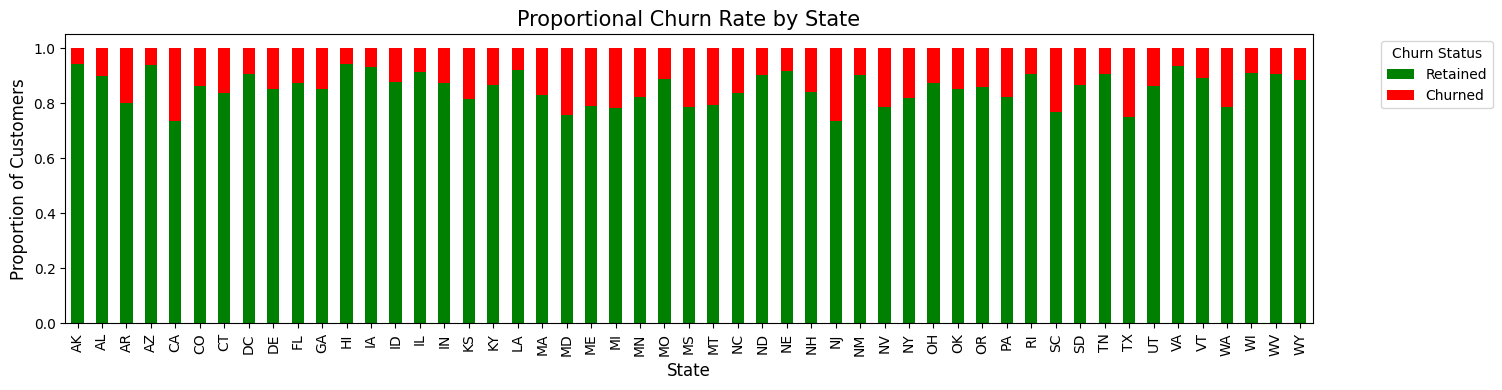

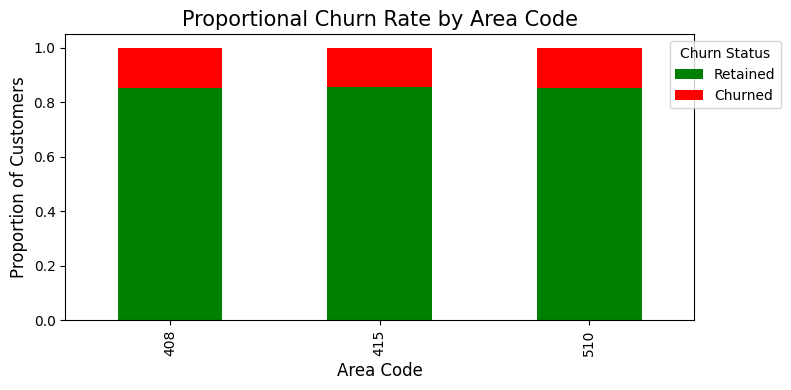

In [320]:
# identify relationships between string features and the target variable
# -- visualize the distribution of the target variable --
col_to_test = ['State', 'Area Code']
for col in col_to_test:
    proportions = pd.crosstab(churn[col], churn['Churn'], normalize='index')
    
    fig_width = 15 if col == 'State' else 8
    
    ax = proportions.plot(kind='bar', 
                          stacked=True, 
                          figsize=(fig_width, 4), 
                          color=['green', 'red'])
    
    plt.title(f'Proportional Churn Rate by {col}', fontsize=15)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Proportion of Customers', fontsize=12)
    
    plt.legend(title='Churn Status', 
               labels=['Retained', 'Churned'], 
               loc='upper right', 
               bbox_to_anchor=(1.15, 1))

    plt.tight_layout() 

    plt.show()


##### From the distribution of string variables, we can see that these two variables have little influence on our target, so we choose to ignore these two variables.
##### Combining the numerical variable distributions, we select the three most relevant variables: Intl Plan, Day Mins, and CustServ Calls.


## Part C: Model Building
### Build and compare three models: Support Vector Machine (SVM), Random Forest, K-Nearest Neighbors (KNN) 


#### Model 1 - Random Forest

##### Random Forest Model assessment and comments
* As a tree-based ensemble algorithm, it does not require feature rescaling.
* A 75/25 stratified train-test split is used to maintain the original class distribution. 
* A pipeline is constructed to standardize the model workflow. 
* It is well-suited for churn prediction due to its robustness to overfitting and ability to handle imbalanced class distributions.

In [321]:
churn.info()

<class 'pandas.DataFrame'>
Index: 3333 entries, 382-4657 to 400-4344
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Account Length  3333 non-null   int64  
 1   Intl Plan       3333 non-null   int64  
 2   VMail Message   3333 non-null   int64  
 3   Day Mins        3333 non-null   float64
 4   Day Calls       3333 non-null   int64  
 5   Eve Mins        3333 non-null   float64
 6   Eve Calls       3333 non-null   int64  
 7   Night Mins      3333 non-null   float64
 8   Night Calls     3333 non-null   int64  
 9   Intl Mins       3333 non-null   float64
 10  Intl Calls      3333 non-null   int64  
 11  CustServ Calls  3333 non-null   int64  
 12  Churn           3333 non-null   int64  
 13  State           3333 non-null   str    
 14  Area Code       3333 non-null   str    
 15  Churn_Status    3333 non-null   str    
dtypes: float64(4), int64(9), str(3)
memory usage: 571.7+ KB


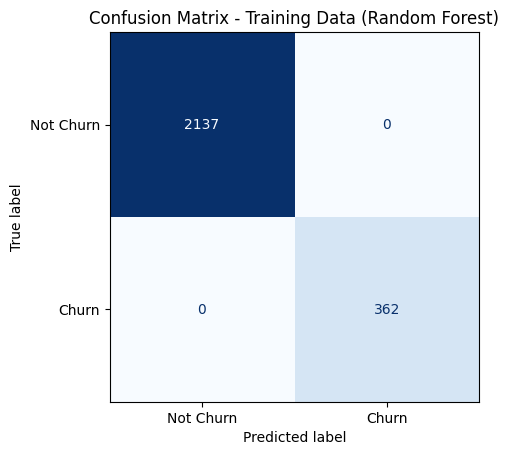

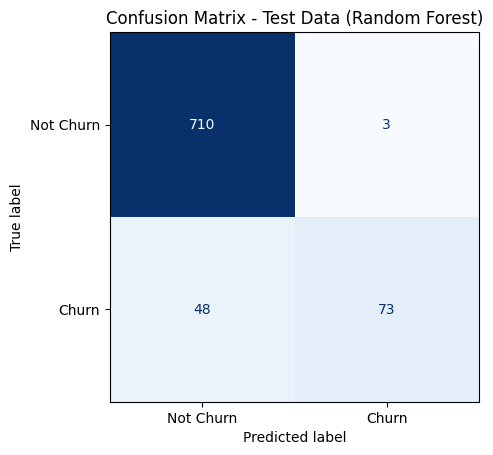

In [322]:
# 1. Define features (X) and target (y)
# Select the 12 numericalfeatures
feature_cols = [
    'Account Length',
    'Intl Plan',
    'VMail Message',
    'Day Mins',
    'Day Calls',
    'Eve Mins',
    'Eve Calls',
    'Night Mins',
    'Night Calls',
    'Intl Mins',
    'Intl Calls',
    'CustServ Calls'
]

X = churn[feature_cols]
y = churn['Churn']

# 2. Split train/test set (stratify to handle class imbalance)
# 75% training, 25% test, keep churn ratio consistent
X_train_rf, X_test_rf, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.25, 
    random_state=1, 
    stratify=y 
)

# 3. Build Pipeline for Random Forest
# Even though RF doesn't need scaling, we use Pipeline to standardize workflow (per requirement)
rf_pipeline = Pipeline([
    ('rf_classifier', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=1
    ))
])

# 4. Train the model via Pipeline
rf_pipeline.fit(X_train_rf, y_train)

# 5. Make predictions
y_pred_train = rf_pipeline.predict(X_train_rf)
y_pred_test = rf_pipeline.predict(X_test_rf)
y_pred_proba_test = rf_pipeline.predict_proba(X_test_rf)[:, 1]

# 6. Plot Confusion Matrix (Train vs Test)
# Training Set
ConfusionMatrixDisplay.from_estimator(
    rf_pipeline,
    X_train_rf,
    y_train,
    cmap="Blues",
    colorbar=False,
    display_labels=["Not Churn", "Churn"]
)
plt.title("Confusion Matrix - Training Data (Random Forest)")
plt.show()

# Test Set
ConfusionMatrixDisplay.from_estimator(
    rf_pipeline,
    X_test_rf,
    y_test,
    cmap="Blues",
    colorbar=False,
    display_labels=["Not Churn", "Churn"]
)
plt.title("Confusion Matrix - Test Data (Random Forest)")
plt.show()



#### Model 2 - K-Nearest Neighbors (KNN) 

##### K-Nearest Neighbors Model assessment and comments
* As a distance-based algorithm, KNN is highly sensitive to the curse of dimensionality. Therefore, we use only the top 3 most predictive features identified in EDA (Intl Plan, Day Mins, CustServ Calls) to optimize model performance.
* KNN requires feature rescaling (standardization) to ensure all features contribute equally to distance calculations, which is critical for reliable predictions.
* A 75/25 stratified train-test split is applied to preserve the original class distribution, ensuring the model is evaluated on a representative dataset.
* A pipeline with standardization is constructed to standardize the end-to-end modeling workflow, preventing data leakage and ensuring reproducibility.

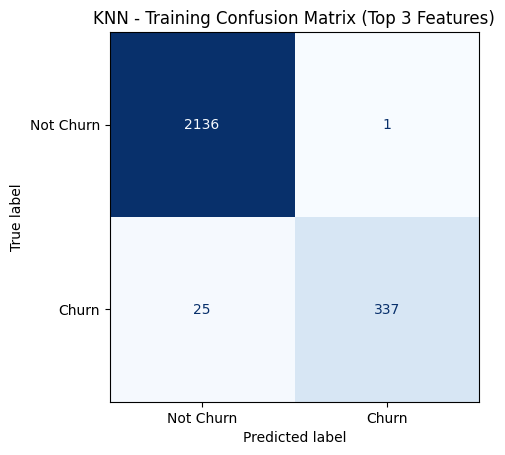

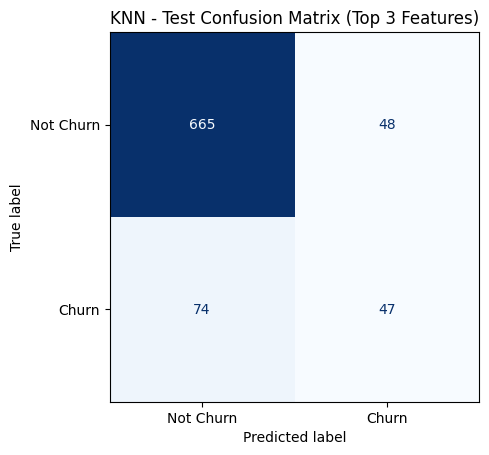

In [323]:
# 1. Define Features & Target
# Selected top 3 most relevant features from EDA
feature_cols = [
    'Intl Plan',
    'Day Mins',
    'CustServ Calls'
]

X = churn[feature_cols]
y = churn['Churn']

# 2. Train / Test Split
X_train_knn, X_test_knn, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=1,
    stratify=y
)

# 3. Build Pipeline (KNN requires StandardScaler)
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),  #KNN rescaling to ensure equal contribution of all features

    ('knn', KNeighborsClassifier(
        n_neighbors=5,
        weights='distance' 
    ))
])

# 4. Train Model
knn_pipeline.fit(X_train_knn, y_train)

# 5. Show Confusion Matrices 

# Training Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    knn_pipeline, X_train_knn, y_train,
    cmap="Blues", colorbar=False,
    display_labels=["Not Churn", "Churn"]
)
plt.title("KNN - Training Confusion Matrix (Top 3 Features)")
plt.show()

# Test Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    knn_pipeline, X_test_knn, y_test,
    cmap="Blues", colorbar=False,
    display_labels=["Not Churn", "Churn"]
)
plt.title("KNN - Test Confusion Matrix (Top 3 Features)")
plt.show()

#### Model 3 - Support Vector Machine (SVM)

##### Support Vector Machine Model assessment and comments
* As a distance-based classifier, SVM is sensitive to feature scales and requires feature rescaling (standardization) for optimal performance.
* To avoid dimensionality issues and improve efficiency, we use only the top 3 most predictive features identified in EDA (Intl Plan, Day Mins, CustServ Calls).
* A 75/25 stratified train-test split is applied to preserve the original class distribution.
* A pipeline with standardization is constructed to standardize the modeling workflow and prevent data leakage.

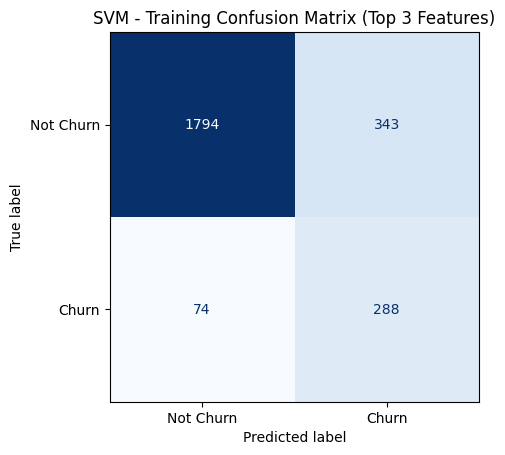

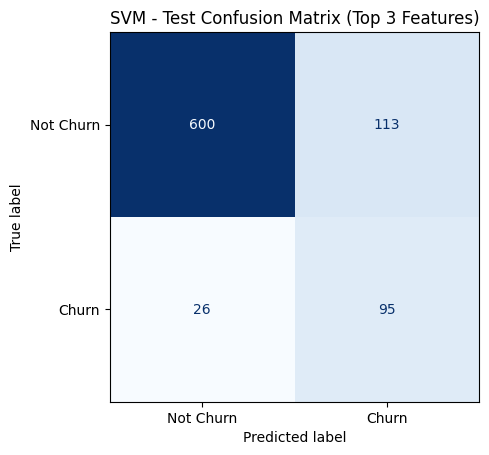

In [324]:
# 1. Define Features & Target
# Selected top 3 most relevant features from EDA
feature_cols = [
    'Intl Plan',
    'Day Mins',
    'CustServ Calls'
]

X = churn[feature_cols]
y = churn['Churn']

# 2. Train / Test Split 
X_train_svm, X_test_svm, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=1,
    stratify=y
)

# 3. Build Pipeline 
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),   
    ('svm', SVC(
        kernel='rbf',              
        class_weight='balanced',  
        probability=True,  
        random_state=1
    ))
])


# 4. Train Model
svm_pipeline.fit(X_train_svm, y_train)

# 5. Show Confusion Matrices
# Training Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    svm_pipeline, X_train_svm, y_train,
    cmap="Blues", colorbar=False,
    display_labels=["Not Churn", "Churn"]
)
plt.title("SVM - Training Confusion Matrix (Top 3 Features)")
plt.show()

# Test Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    svm_pipeline, X_test_svm, y_test,
    cmap="Blues", colorbar=False,
    display_labels=["Not Churn", "Churn"]
)
plt.title("SVM - Test Confusion Matrix (Top 3 Features)")
plt.show()

## Part D: Model Evaluation
### Evaluate and compare the three models using:
* Accuracy
* Precision
* Recall
* F1-score
* ROC Curve / AUC
* Discuss trade-oﬀs (e.g., false negatives vs false positives)
* How you address the issue of bias vs. variance

In [325]:
# 1. Evaluate Random Forest (using its own X_test_rf)
y_pred_rf = rf_pipeline.predict(X_test_rf)
y_prob_rf = rf_pipeline.predict_proba(X_test_rf)[:, 1]

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_prec = precision_score(y_test, y_pred_rf)
rf_rec = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

# 2. Evalueate KNN 评估 (using its own X_test_knn)
y_pred_knn = knn_pipeline.predict(X_test_knn)
y_prob_knn = knn_pipeline.predict_proba(X_test_knn)[:, 1]

knn_acc = accuracy_score(y_test, y_pred_knn)
knn_prec = precision_score(y_test, y_pred_knn)
knn_rec = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)
knn_auc = roc_auc_score(y_test, y_prob_knn)

# 3. Evaluate SVM (using its own X_test_svm)
y_pred_svm = svm_pipeline.predict(X_test_svm)
y_prob_svm = svm_pipeline.predict_proba(X_test_svm)[:, 1]

svm_acc = accuracy_score(y_test, y_pred_svm)
svm_prec = precision_score(y_test, y_pred_svm)
svm_rec = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)
svm_auc = roc_auc_score(y_test, y_prob_svm)

# Generate comparison table
results = {
    "Model": ["Random Forest", "KNN", "SVM"],
    "Accuracy": [round(rf_acc,4), round(knn_acc,4), round(svm_acc,4)],
    "Precision": [round(rf_prec,4), round(knn_prec,4), round(svm_prec,4)],
    "Recall": [round(rf_rec,4), round(knn_rec,4), round(svm_rec,4)],
    "F1 Score": [round(rf_f1,4), round(knn_f1,4), round(svm_f1,4)],
    "AUC": [round(rf_auc,4), round(knn_auc,4), round(svm_auc,4)]
}

df_compare = pd.DataFrame(results)

print("Model Performance Comparison (Threshold = 0.5)")
print("="*60)
print(df_compare.to_string(index=False))

Model Performance Comparison (Threshold = 0.5)
        Model  Accuracy  Precision  Recall  F1 Score    AUC
Random Forest    0.9388     0.9605  0.6033    0.7411 0.9201
          KNN    0.8537     0.4947  0.3884    0.4352 0.7881
          SVM    0.8333     0.4567  0.7851    0.5775 0.8747


##### To address bias and variance, we consider the inherent characteristics of each model and apply appropriate strategies:
* For Random Forest, as an ensemble model, it naturally balances low bias and low variance. By building multiple independent decision trees and averaging their predictions, it reduces high variance that often occurs in single trees. We use all 12 features since Random Forest is robust to dimensionality and requires little tuning to avoid overfitting.

* For KNN, which is a lazy learner with high variance and sensitivity to noise and feature scale, we reduce variance by using only the top 3 important features to avoid the curse of dimensionality. We also apply feature standardization and use a reasonable k value to balance between underfitting (high bias) and overfitting (high variance).

* For SVM, which has high variance due to its kernel function, we reduce variance by feature scaling and using only 3 key features. We also set class_weight='balanced' to reduce bias caused by class imbalance. The RBF kernel is chosen to achieve good generalization without excessive overfitting.

* Overall, we manage bias-variance trade-off through feature selection, standardization, model choice, and appropriate parameter settings, ensuring all models generalize well on unseen test data.

##### Business implications of threshold choice 
* The choice of classification threshold directly influences the trade-off between false positives and false negatives, which carries important business consequences in churn prediction. 
* A lower threshold identifies more customers as likely to churn, increasing recall but reducing precision. This strategy minimizes missed churners (false negatives) and preserves revenue, but raises marketing costs by targeting too many non-churning customers (false positives). 
* A higher threshold improves precision, reducing wasted resources on false positives, but increases false negatives, allowing more actual churners to leave undetected. For most business contexts, missing churners is more costly than over-targeting, so a moderately low threshold is often preferred. 
* In this analysis, all models are compared using a consistent default threshold of 0.5 to ensure fair and practical evaluation.


## Part E: Model Interpretation